In [1]:
import numpy 
import os
import scipy
import ipywidgets
from scipy.ndimage import label, center_of_mass, sum as ndi_sum
import scipp as sc
from scippneutron.conversion import graph
import matplotlib.pyplot as plt

import ipywidgets as widgets

import inspect
import plopp

import read_h5
import plot_data_ddict
import magic_graphs
import magic_scipp
import peak_find
import get_ub
import integrate_peaks
import operations_with_da

import importlib
# importlib.reload(operations_with_da)

In [2]:
def assign_dg_to_da_coords(dg: sc.DataGroup, da: sc.DataArray, prefix:str=""):
    for s_key in dg.keys():
        da.coords[f"{prefix}_{s_key}"] = dg[s_key]

In [3]:
f_nexus_data = r"/Users/iuriikibalin/Downloads/sim_c60/mccode.h5"
f_nexus_data = r"/Users/iuriikibalin/Repositories/magic/sim_c60_all/mccode.h5"
f_nexus_data = r"/Users/iuriikibalin/Repositories/magic/sim_c60_one/mccode.h5"
dg_magic = read_h5.read_magic_from_nexus(f_nexus_data)
dg_magic

DataGroup(sizes={'event': 7645001, 'counts': 101}, keys=[
    delta_L: Variable({}),
    delta_t: Variable({}),
    source_position: Variable({}),
    sample: DataGroup(5, {}),
    detector_a: DataArray({'event': 7645001}),
    cave_monitor: DataArray({'counts': 101}),
    tp_position: Variable({}),
])

In [ ]:
import scippnexus
dg_mcstas = scippnexus.load(f_nexus_data)

In [5]:
dg_mcstas['entry1']['instrument']['components']['0114_monitor_at_sample']['output']['monitor_at_sample_1782224615_t']

KeyError: 'monitor_at_sample_1782224615_t'

In [9]:
dg_sample = dg_magic['sample']
da_det_a = dg_magic['detector_a']

In [10]:
da_laue = da_det_a.groupby('voxel_ID').sum('event')
da_laue

<scipp.DataArray>
Dimensions: Sizes[voxel_ID:490603, ]
Coordinates:
* ID_0                        int64  [dimensionless]  ()  1
* N_a                         int64  [dimensionless]  ()  128
* N_c                         int64  [dimensionless]  ()  32
* N_vs                        int64  [dimensionless]  ()  60
* a_b                       float64              [m]  ()  -0.722903
* a_t                       float64              [m]  ()  0.252863
* b_b                       float64              [m]  ()  -1.078
* b_t                       float64              [m]  ()  0.416545
* casette_delta_gamma       float64            [rad]  ()  0.018326
* casette_omega             float64            [rad]  ()  -0.158842
* gamma                     float64            [rad]  ()  0.261799
* position                  vector3              [m]  ()  (-0.034, -0.674198, 154.497)
* r_d                       float64              [m]  ()  1
* r_vs                      float64              [m]  ()  0.53
* voxel_ID                    int64  [dimensionless]  (voxel_ID)  [1, 2, ..., 491519, 491520]
Data:
                            float64  [dimensionless]  (voxel_ID)  [0.0079045, 0.0282768, ..., 0.000213037, 0.00349343]  [1.20362e-05, 0.000208755, ..., 4.53849e-08, 1.2167e-05]

In [11]:
da_det_a

<scipp.DataArray>
Dimensions: Sizes[event:7645001, ]
Coordinates:
* ID_0                        int64  [dimensionless]  ()  1
* N_a                         int64  [dimensionless]  ()  128
* N_c                         int64  [dimensionless]  ()  32
* N_vs                        int64  [dimensionless]  ()  60
* a_b                       float64              [m]  ()  -0.722903
* a_t                       float64              [m]  ()  0.252863
* b_b                       float64              [m]  ()  -1.078
* b_t                       float64              [m]  ()  0.416545
* casette_delta_gamma       float64            [rad]  ()  0.018326
* casette_omega             float64            [rad]  ()  -0.158842
* event_position_local_mcstas  vector3              [m]  (event)  [(0.547119, 0.217306, 0.964845), (1.04934, 0.182059, 0.95505), ..., (0.225487, -0.795679, 1.09848), (0.238113, -0.516759, 1.00034)]
* gamma                     float64            [rad]  ()  0.261799
* position                  vector3              [m]  ()  (-0.034, -0.674198, 154.497)
* r_d                       float64              [m]  ()  1
* r_vs                      float64              [m]  ()  0.53
* toa                       float64              [s]  (event)  [0.043424, 0.062466, ..., 0.0847183, 0.0648537]
* voxel_ID                    int64  [dimensionless]  (event)  [93180, 386257, ..., 122665, 27267]
Data:
                            float64  [dimensionless]  (event)  [0.00118968, 0.000967366, ..., 1.44922e-05, 0.00178977]  [1.41533e-06, 9.35797e-07, ..., 2.10023e-10, 3.20326e-06]

In [12]:
ind_max = numpy.argmax(da_laue.data.values)
voxel_id = da_laue.coords['voxel_ID'][ind_max]
voxel_id

<scipp.Variable> ()      int64  [dimensionless]  86051

In [13]:
voxel_id

<scipp.Variable> ()      int64  [dimensionless]  86051

In [14]:
da_det_a = da_det_a.transform_coords(("event_gamma",'event_nu', 'event_position_global'), graph=magic_graphs.graph_detector, rename_dims=False)

In [15]:
assign_dg_to_da_coords(dg_magic['sample'], da_det_a, prefix="sample")
da_det_a.coords['tp_position'] = dg_magic['tp_position']
da_det_a.coords['source_position'] = dg_magic['source_position']
da_det_a.coords['delta_L'] = dg_magic['delta_L']
da_det_a.coords['delta_t'] = dg_magic['delta_t']
da_det_a = da_det_a.transform_coords(("Q_vec_rot","norm_Q", "two_theta"), graph=magic_graphs.graph_qvec)

In [16]:
da_det_a

<scipp.DataArray>
Dimensions: Sizes[event:7645001, ]
Coordinates:
  ID_0                        int64  [dimensionless]  ()  1
  L1                        float64              [m]  ()  159.397
  L2                        float64              [m]  (event)  [1.127, 1.43029, ..., 1.37478, 1.14754]
  Ltotal                    float64              [m]  (event)  [160.524, 160.827, ..., 160.772, 160.545]
  N_a                         int64  [dimensionless]  ()  128
  N_c                         int64  [dimensionless]  ()  32
  N_vs                        int64  [dimensionless]  ()  60
  Q_vec                     vector3           [1/Å]  (event)  [(-4.3452, -1.19937, 1.89577), (-3.78585, -0.548143, 2.34152), ..., (-1.1426, 1.80301, 0.842729), (-1.75226, 1.85681, 0.885735)]
* Q_vec_rot                 vector3           [1/Å]  (event)  [(-4.3452, -1.19937, 1.89577), (-3.78585, -0.548143, 2.34152), ..., (-1.1426, 1.80301, 0.842729), (-1.75226, 1.85681, 0.885735)]
  Qx                        float64           [1/Å]  (event)  [-4.3452, -3.78585, ..., -1.1426, -1.75226]
  Qy                        float64           [1/Å]  (event)  [-1.19937, -0.548143, ..., 1.80301, 1.85681]
  Qz                        float64           [1/Å]  (event)  [1.89577, 2.34152, ..., 0.842729, 0.885735]
  a_b                       float64              [m]  ()  -0.722903
  a_t                       float64              [m]  ()  0.252863
  b_b                       float64              [m]  ()  -1.078
  b_t                       float64              [m]  ()  0.416545
  casette_delta_gamma       float64            [rad]  ()  0.018326
  casette_omega             float64            [rad]  ()  -0.158842
  delta_L                   float64              [m]  ()  0
  delta_t                   float64              [s]  ()  0.003
* event_gamma               float64            [rad]  (event)  [0.777861, 1.09434, ..., 0.464211, 0.496201]
* event_nu                  float64            [rad]  (event)  [0.191331, 0.127958, ..., -0.61507, -0.467236]
  event_position_global     vector3              [m]  (event)  [(0.742447, -0.459882, 155.286), (1.2266, -0.491679, 155.148), ..., (0.468709, -1.46747, 155.501), (0.453771, -1.19107, 155.398)]
  event_position_local      vector3              [m]  (event)  [(0.545978, 0.214316, 0.962341), (1.04926, 0.182519, 0.954721), ..., (0.225724, -0.793269, 1.0999), (0.237961, -0.516873, 0.996521)]
* event_position_local_mcstas  vector3              [m]  (event)  [(0.547119, 0.217306, 0.964845), (1.04934, 0.182059, 0.95505), ..., (0.225487, -0.795679, 1.09848), (0.238113, -0.516759, 1.00034)]
  gamma                     float64            [rad]  ()  0.261799
  incident_beam             vector3              [m]  ()  (0, 0, 159.397)
* norm_Q                    float64           [1/Å]  (event)  [4.89011, 4.48507, ..., 2.2949, 2.70235]
  position                  vector3              [m]  ()  (-0.034, -0.674198, 154.497)
  r_d                       float64              [m]  ()  1
  r_vs                      float64              [m]  ()  0.53
  sample_chi                float64            [rad]  ()  0
* sample_offset             vector3              [m]  ()  (0, 0, 0)
  sample_omega              float64            [rad]  ()  0
  sample_phi                float64            [rad]  ()  0
  sample_position           vector3              [m]  ()  (-0.034, -0.674198, 154.497)
  sample_rotation         rotation3  [dimensionless]  ()  (1+0i+0j+0k)
  scattered_beam            vector3              [m]  (event)  [(0.776447, 0.214316, 0.78824), (1.2606, 0.182519, 0.650622), ..., (0.502709, -0.793269, 1.004), (0.487771, -0.516873, 0.900977)]
  source_position           vector3              [m]  ()  (-0.034, -0.674198, -4.89973)
  toa                       float64              [s]  (event)  [0.043424, 0.062466, ..., 0.0847183, 0.0648537]
  tof                       float64              [s]  (event)  [0.040424, 0.059466, ..., 0.0817183, 0.0618537]
  tp_position        

In [17]:
# Given by User
cell_a = sc.scalar(14.04078, unit="angstrom")
cell_b = sc.scalar(14.04078, unit="angstrom")
cell_c = sc.scalar(14.04078, unit="angstrom")
cell_alpha = sc.scalar(90., unit="deg")
cell_beta = sc.scalar(90., unit="deg")
cell_gamma = sc.scalar(90., unit="deg")

# First estimation
euler_alpha = sc.scalar(0., unit="deg")
euler_beta = sc.scalar(0., unit="deg")
euler_gamma = sc.scalar(0., unit="deg")

In [18]:
da_det_a.coords["cell_a"] = cell_a
da_det_a.coords["cell_b"] = cell_b
da_det_a.coords["cell_c"] = cell_c
da_det_a.coords["cell_alpha"] = cell_alpha
da_det_a.coords["cell_beta"] = cell_beta
da_det_a.coords["cell_gamma"] = cell_gamma
da_det_a.coords["euler_alpha"] = euler_alpha
da_det_a.coords["euler_beta"] = euler_beta
da_det_a.coords["euler_gamma"] = euler_gamma
magic_scipp.remove_coords_in_da(da_det_a, "h", "k", "l", "h_reduced", "k_reduced", "l_reduced", "u_matrix", "ub_matrix", "b_matrix")

da_det_a = da_det_a.transform_coords(("h","k","l","h_reduced","k_reduced","l_reduced"), graph=magic_graphs.graph_hkl)  

In [19]:
flag = da_det_a.coords['voxel_ID'] == voxel_id


In [20]:
da_det_a_pixel = da_det_a[flag]

In [21]:
da_det_a.coords.keys()

<scipp.Dict.keys {position, event_position_local_mcstas, voxel_ID, toa, casette_omega, gamma, ID_0, N_vs, N_a, N_c, r_d, r_vs, a_t, b_t, a_b, b_b, casette_delta_gamma, voxel_ID_VS, voxel_ID_a, voxel_ID_c, event_position_local, event_gamma, event_nu, event_position_global, sample_position, sample_omega, sample_chi, sample_phi, sample_offset, tp_position, source_position, delta_L, delta_t, scattered_beam, incident_beam, tof, sample_rotation, L2, two_theta, L1, Ltotal, wavelength, Qx, Qy, Qz, Q_vec, norm_Q, Q_vec_rot, cell_a, cell_b, cell_c, cell_alpha, cell_beta, cell_gamma, euler_alpha, euler_beta, euler_gamma, b_matrix, u_matrix, ub_matrix, hkl_vec, h, k, l, h_reduced, k_reduced, l_reduced}>

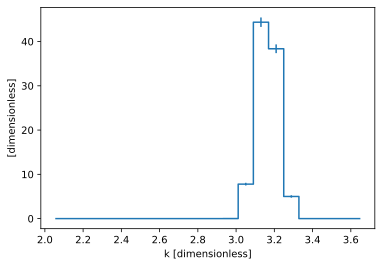

In [22]:
da_det_a_pixel.hist(k=20).plot()

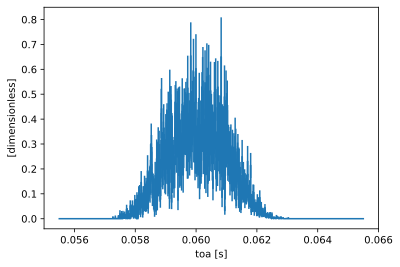

In [23]:
bin_toa = sc.linspace(dim='toa', start=0.0555, stop=0.0655, num=1001,endpoint=True, unit='s')
da_det_a_pixel.hist(toa=bin_toa).plot()

In [28]:
x = da_det_a_pixel.hist(toa=bin_toa).coords['toa'].values

In [31]:
y = da_det_a_pixel.hist(toa=bin_toa).data.values

In [34]:
numpy.savetxt('x.txt',x)
numpy.savetxt('y.txt',y)

In [ ]:
da_det_a_pixel.hist(toa=bin_toa).plot()

In [7]:

da_det_a_pixel.hist(toa=bin_toa).plot()

NameError: name 'da_det_a_pixel' is not defined

In [ ]:

da_det_a_pixel.hist(toa=bin_toa).plot()

In [ ]:
(bin_toa[1]-bin_toa[0]).to(unit='micros')

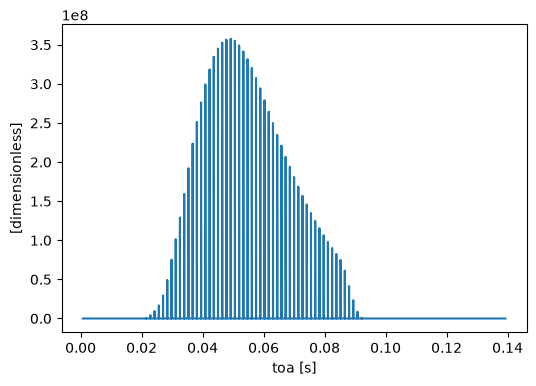

In [8]:
dg_magic['cave_monitor'].hist(toa=10000).plot()

/var/folders/21/ydkdtl7s58l9yl1k98746cj40000gp/T/ipykernel_67277/2520153819.py:61: RuntimeWarning: invalid value encountered in divide
  nu    = np.rad2deg(np.arcsin(z / r))     # vertical angle


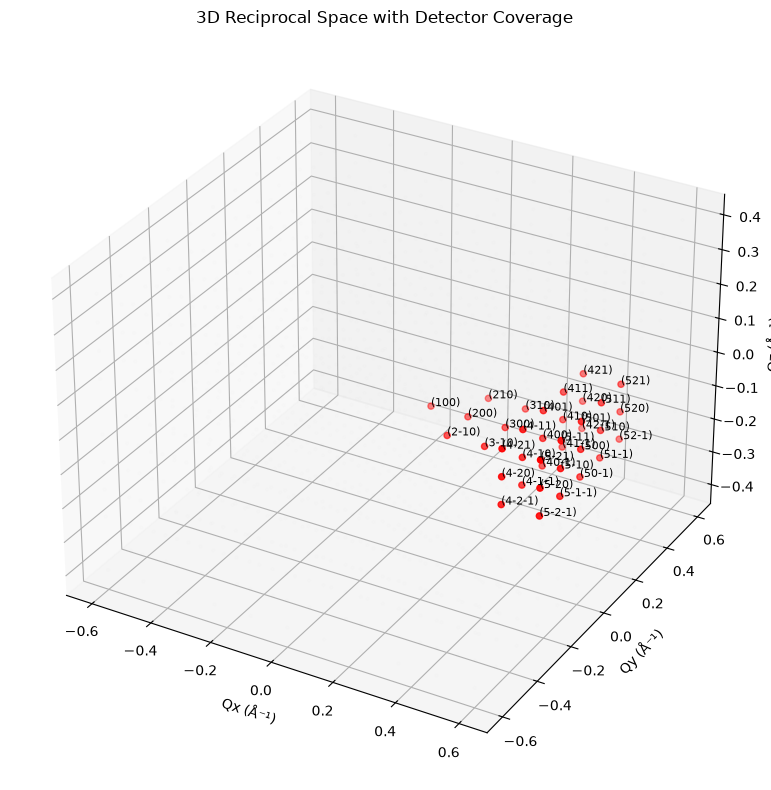

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


# ------------------------------------------------------------
# 1. Reciprocal lattice from unit cell
# ------------------------------------------------------------
def reciprocal_lattice(a, b, c, alpha, beta, gamma):
    # Convert to radians
    alpha, beta, gamma = map(np.deg2rad, (alpha, beta, gamma))

    # Direct lattice metric tensor
    volume = a*b*c*np.sqrt(
        1 + 2*np.cos(alpha)*np.cos(beta)*np.cos(gamma)
        - np.cos(alpha)**2 - np.cos(beta)**2 - np.cos(gamma)**2
    )

    astar = (b*c*np.sin(alpha)) / volume
    bstar = (a*c*np.sin(beta)) / volume
    cstar = (a*b*np.sin(gamma)) / volume

    return astar, bstar, cstar


# ------------------------------------------------------------
# 2. Generate (h,k,l) grid
# ------------------------------------------------------------
def generate_hkl(hmax, kmax, lmax):
    h = np.arange(-hmax, hmax+1)
    k = np.arange(-kmax, kmax+1)
    l = np.arange(-lmax, lmax+1)
    H, K, L = np.meshgrid(h, k, l, indexing='ij')
    return np.vstack([H.ravel(), K.ravel(), L.ravel()]).T


# ------------------------------------------------------------
# 3. Compute Q vectors in lab frame using UB matrix
# ------------------------------------------------------------
def compute_Q_vectors(hkl, UB):
    return (UB @ hkl.T).T


# ------------------------------------------------------------
# 4. Ewald sphere limits
# ------------------------------------------------------------
def ewald_limits(lambda_min, lambda_max):
    kmin = 2*np.pi / lambda_max
    kmax = 2*np.pi / lambda_min
    return kmin, kmax


# ------------------------------------------------------------
# 5. Detector angular coverage (γ, ν)
# ------------------------------------------------------------
def detector_mask(Q, gamma_min, gamma_max, nu_min, nu_max):
    # Convert to spherical angles
    x, y, z = Q[:,0], Q[:,1], Q[:,2]
    r = np.linalg.norm(Q, axis=1)
    gamma = np.rad2deg(np.arctan2(y, x))     # horizontal angle
    nu    = np.rad2deg(np.arcsin(z / r))     # vertical angle

    mask = (
        (gamma >= gamma_min) & (gamma <= gamma_max) &
        (nu    >= nu_min)    & (nu    <= nu_max)
    )
    return mask


# ------------------------------------------------------------
# 6. Plotting
# ------------------------------------------------------------
def plot_reciprocal_space(Q, hkl, mask):
    fig = plt.figure(figsize=(10,8))
    ax = fig.add_subplot(111, projection='3d')

    # All points
    ax.scatter(Q[:,0], Q[:,1], Q[:,2], s=5, alpha=0.1, color='gray')

    # Points inside detector coverage
    Qdet = Q[mask]
    hkldet = hkl[mask]
    ax.scatter(Qdet[:,0], Qdet[:,1], Qdet[:,2], s=20, color='red')

    # Label visible peaks
    for q, (h,k,l) in zip(Qdet, hkldet):
        ax.text(q[0], q[1], q[2], f"({h}{k}{l})", fontsize=8)

    ax.set_xlabel("Qx (Å⁻¹)")
    ax.set_ylabel("Qy (Å⁻¹)")
    ax.set_zlabel("Qz (Å⁻¹)")
    ax.set_title("3D Reciprocal Space with Detector Coverage")
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 7. Example usage
# ------------------------------------------------------------
if __name__ == "__main__":
    # Unit cell (example)
    a, b, c = 4.5, 4.5, 6.0
    alpha, beta, gamma = 90, 90, 120

    # UB matrix (example)
    UB = np.array([
        [0.12, 0.00, 0.00],
        [0.00, 0.12, 0.00],
        [0.00, 0.00, 0.08]
    ])

    # Generate HKL grid
    hkl = generate_hkl(5, 5, 5)

    # Compute Q vectors
    Q = compute_Q_vectors(hkl, UB)

    # Wavelength range
    lambda_min = 1.5
    lambda_max = 2.5
    kmin, kmax = ewald_limits(lambda_min, lambda_max)

    # Detector angular limits (example)
    gamma_min, gamma_max = -30, 30
    nu_min, nu_max = -10, 10

    # Apply detector mask
    mask = detector_mask(Q, gamma_min, gamma_max, nu_min, nu_max)

    # Plot
    plot_reciprocal_space(Q, hkl, mask)



In [11]:
hkl = generate_hkl(5, 5, 5)

In [12]:
hkl

array([[-5, -5, -5],
       [-5, -5, -4],
       [-5, -5, -3],
       ...,
       [ 5,  5,  3],
       [ 5,  5,  4],
       [ 5,  5,  5]], shape=(1331, 3))

In [5]:
import numpy as np

data = np.array([
    [ 1,  0,  0,   -12.3,   3.5,   1.20],
    [ 1,  1,  0,    -8.1,   5.2,   1.35],
    [ 2,  0,  0,     4.7,   1.1,   1.80],
    [ 0,  1,  1,    10.2,  -2.4,   2.10],
    [ 2,  1,  0,    15.8,   0.9,   1.95],
    [ 1,  2,  0,    22.4,   4.3,   2.40],
    [ 0,  0,  2,   -25.0,  -6.0,   1.10],
    [ 2,  2,  1,    -5.5,  -1.2,   1.70],
    [ 3,  0,  0,     8.9,   7.1,   2.20],
    [ 1,  1,  2,    18.3,  -3.8,   1.50],
])

print(data)


[[  1.     0.     0.   -12.3    3.5    1.2 ]
 [  1.     1.     0.    -8.1    5.2    1.35]
 [  2.     0.     0.     4.7    1.1    1.8 ]
 [  0.     1.     1.    10.2   -2.4    2.1 ]
 [  2.     1.     0.    15.8    0.9    1.95]
 [  1.     2.     0.    22.4    4.3    2.4 ]
 [  0.     0.     2.   -25.    -6.     1.1 ]
 [  2.     2.     1.    -5.5   -1.2    1.7 ]
 [  3.     0.     0.     8.9    7.1    2.2 ]
 [  1.     1.     2.    18.3   -3.8    1.5 ]]


In [ ]:
import numpy as np

def generate_peak_data(UB, R, hmax, kmax, lmax, lambda_min, lambda_max):
    """
    Generate synthetic diffraction peak data based on:
    - UB matrix (3x3)
    - crystal rotation matrix R (3x3)
    - HKL range: -hmax..hmax etc.
    - wavelength range (lambda_min, lambda_max)

    Returns array with columns:
    [h, k, l, gamma_deg, nu_deg, wavelength]
    """

    # --- 1. Generate HKL grid ---
    h = np.arange(-hmax, hmax+1)
    k = np.arange(-kmax, kmax+1)
    l = np.arange(-lmax, lmax+1)
    H, K, L = np.meshgrid(h, k, l, indexing='ij')
    hkl = np.vstack([H.ravel(), K.ravel(), L.ravel()]).T

    # Remove (0,0,0)
    hkl = hkl[np.any(hkl != 0, axis=1)]

    # --- 2. Compute Q vectors in lab frame ---
    # Apply UB and then rotation R
    Q = (R @ (UB @ hkl.T)).T

    # Magnitude of Q
    Qnorm = np.linalg.norm(Q, axis=1)

    # --- 3. Compute wavelength from Bragg condition ---
    # |Q| = 4π sinθ / λ  →  λ = 4π sinθ / |Q|
    # For Laue TOF instruments, scattering angle 2θ is determined by Q direction:
    # cos(2θ) = -Qx / |Q|  (assuming beam along +x)
    #
    # But for simplicity, we assume elastic scattering:
    # λ = 2π / |k|  and |k| = |Q|/2  →  λ = 4π / |Q|
    #
    # This is a good approximation for generating synthetic data.

    wavelength = 4*np.pi / Qnorm

    # --- 4. Apply wavelength limits ---
    mask = (wavelength >= lambda_min) & (wavelength <= lambda_max)
    hkl = hkl[mask]
    Q = Q[mask]
    wavelength = wavelength[mask]

    # --- 5. Convert Q direction to detector angles (γ, ν) ---
    Qx, Qy, Qz = Q[:,0], Q[:,1], Q[:,2]
    ki = numpy.array([0,0,2*np.pi/wavelength ])
    kf = ki + Q
    kf_x, kf_y, kf_z = kf[:,0], kf[:,1], kf[:,2]
    
    r = np.linalg.norm(Q, axis=1)

    gamma = np.rad2deg(np.arctan2(Qy, Qx))      # horizontal angle
    nu    = np.rad2deg(np.arcsin(Qz / r))       # vertical angle

    # --- 6. Build final array ---
    result = np.column_stack([hkl[:,0], hkl[:,1], hkl[:,2], gamma, nu, wavelength])
    return result


In [20]:
# Example UB matrix
UB = np.array([
    [0.12, 0.00, 0.00],
    [0.00, 0.12, 0.00],
    [0.00, 0.00, 0.08]
])

# Example rotation matrix (identity = no rotation)
R = np.eye(3)

# Generate peaks
data = generate_peak_data(
    UB=UB,
    R=R,
    hmax=9, kmax=9, lmax=9,
    lambda_min=0.5,
    lambda_max=6.0
)

print(data)


[]


In [21]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import FloatSlider, VBox, HBox, interactive_output
from IPython.display import display

# ---------------------------------------------------------
# INPUT: your array with columns (h, k, l, gamma, nu, wavelength)
# ---------------------------------------------------------
# Example placeholder:
# data = np.load("your_array.npy")
# Columns: 0=h, 1=k, 2=l, 3=gamma, 4=nu, 5=wavelength

# For demonstration, create dummy data:
# data = np.random.rand(100,6)


# ---------------------------------------------------------
# Plotting function
# ---------------------------------------------------------
def plot_hkl(gmin, gmax, nmin, nmax, lmin, lmax):
    plt.figure(figsize=(8,6))

    # Mask based on user limits
    mask = (
        (data[:,3] >= gmin) & (data[:,3] <= gmax) &
        (data[:,4] >= nmin) & (data[:,4] <= nmax) &
        (data[:,5] >= lmin) & (data[:,5] <= lmax)
    )

    d = data[mask]

    # Scatter plot
    ax = plt.scatter(d[:,3], d[:,4], s=40, color="red")

    # Label each point with (hkl)
    for h, k, l, g, n, lam in d:
        plt.text(g, n, f"({int(h)}{int(k)}{int(l)})", fontsize=8)

    plt.xlabel("gamma (deg)")
    plt.ylabel("nu (deg)")
    plt.xlim((gmin,gmax))
    plt.ylim((nmin,nmax))
    
    plt.title("HKL Peaks in Detector Coordinates")
    plt.grid(True)
    plt.show()


# ---------------------------------------------------------
# Widgets
# ---------------------------------------------------------
gamma_min = FloatSlider(description="γ min", value=-30, min=-180, max=180, step=1)
gamma_max = FloatSlider(description="γ max", value=30, min=-180, max=180, step=1)

nu_min = FloatSlider(description="ν min", value=-10, min=-90, max=90, step=1)
nu_max = FloatSlider(description="ν max", value=10, min=-90, max=90, step=1)

lambda_min = FloatSlider(description="λ min", value=0.8, min=0.1, max=10, step=0.01)
lambda_max = FloatSlider(description="λ max", value=2.5, min=0.1, max=10, step=0.01)

controls = VBox([
    HBox([gamma_min, gamma_max]),
    HBox([nu_min, nu_max]),
    HBox([lambda_min, lambda_max])
])

out = interactive_output(
    plot_hkl,
    {
        "gmin": gamma_min,
        "gmax": gamma_max,
        "nmin": nu_min,
        "nmax": nu_max,
        "lmin": lambda_min,
        "lmax": lambda_max
    }
)

display(controls, out)



Output()